# Comparing my implementation of diffusion maps against the one in pydiffmap

## Imports
Tools from my diffusion maps code (adapted from Jon's code)

### *VERSUS*

the pydiffmap package

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload
from scipy.io import savemat
import DAPyr as dap
from pydiffmap import diffusion_map as dm
from pydiffmap.visualization import embedding_plot, data_plot
from sklearn.neighbors import NearestNeighbors
import scipy.sparse as sps
from scipy.spatial.distance import pdist, squareform, cdist
import scipy.sparse.linalg as spsl
from scipy.sparse import csr_matrix, diags
from scipy.sparse.linalg import eigs, eigsh
reload(dap)
reload(dm)


<module 'pydiffmap.diffusion_map' from '/Users/etto/miniconda3/envs/etto/lib/python3.11/site-packages/pydiffmap/diffusion_map.py'>

## Some test datasets

make_sw_pdm makes a basic swiss roll. The parameter $b$ controls whether and how the density of points along the roll decreases as you move further out from the center.

make_helix makes a toroidal helix similar to what is used in the Coifman and Lafon 2006 Diffusion Maps paper.

In [2]:
def make_sw_pdm(m=10000, b=1):
        # set parameters
    length_phi = 15   #length of swiss roll in angular direction
    length_Z = 15     #length of swiss roll in z direction
    sigma = 0.1       #noise strength
    
    # create dataset
    phi = length_phi*np.random.rand(m) ** b
    xi = np.random.rand(m)
    Y = length_Z*np.random.rand(m)
    X = 1./6*(phi + sigma*xi)*np.sin(phi)
    Z = 1./6*(phi + sigma*xi)*np.cos(phi)
    
    swiss_roll = np.array([X, Y, Z]).transpose()

    return swiss_roll, phi
    
    # check that we have the right shape
    print(swiss_roll.shape)

def make_helix(r1=6, r2=10, nc=8, n_samples=1000, noise=0, random_state=58):
    rng = np.random.default_rng(random_state)
    pt = np.linspace(0,2*np.pi, n_samples)
    X = np.zeros((n_samples,3))
    X[:,0] = (r2 + r1 * np.cos(nc*pt) ) * np.cos(pt)
    X[:,1] = (r2 + r1 * np.cos(nc*pt) ) * np.sin(pt)
    X[:,2] = r1 * np.sin(nc*pt)
    if noise > 0.0:
        X += rng.normal(scale=noise, size=X.shape)

    return X, pt

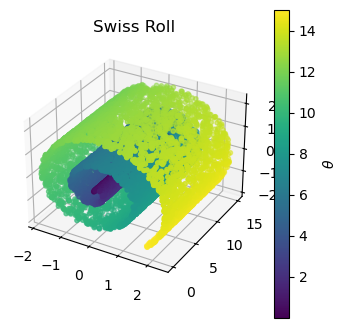

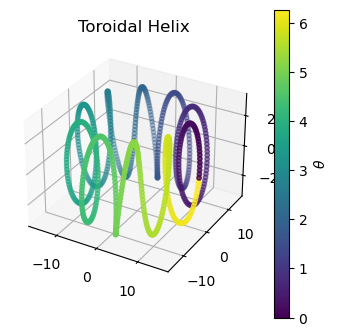

In [3]:
X, t = make_sw_pdm(m = 10000, b=1.0)

fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=t, cmap=plt.cm.viridis, s=10)
ax.set_title("Swiss Roll")
plt.colorbar(scatter, ax=ax, label="$\\theta$")
plt.show()
plt.close()

fig = plt.figure(figsize=(4, 4))
Xh, th = make_helix(n_samples=800, r1=3, r2=12, nc=10, noise=0.0)
ax = fig.add_subplot(111, projection='3d')
ax.set_title("Toroidal Helix")
scatter = ax.scatter(Xh[:, 0], Xh[:, 1], Xh[:, 2], c=th, cmap=plt.cm.viridis, s=10)
plt.colorbar(scatter, ax=ax, label="$\\theta$")
plt.show()
plt.close()


## Experiments

Starting with the swiss roll, we fix the same knn and run both diffusion maps versions on the above dataset.

In [20]:
neighbor_params = {'n_jobs': -1, 'algorithm': 'ball_tree'}
mydmap = dm.DiffusionMap.from_sklearn(n_evecs=2, k=300, epsilon=0.03125, alpha=0.0, neighbor_params=neighbor_params)
dmap = mydmap.fit_transform(X)

eig_vecs, eig_vals, a_train, bw, keeps = dap.MISC.diff_map(X, Neig=2, knn=300, bw=0.03125, eigmin=0.0, Ns=1, train_frac=1, alpha = 0.0)
emb = (eig_vecs * eig_vals)

pdm_phi1_min = dmap[:,0].min()
pdm_phi1_max = dmap[:,0].max()
pdm_phi2_min = dmap[:,1].min()
pdm_phi2_max = dmap[:,1].max()
phi1_min = emb[:,1].min()
phi1_max = emb[:,1].max()
phi2_min = emb[:,2].min()
phi2_max = emb[:,2].max()

plot_1_min = min(phi1_min, pdm_phi1_min)
plot_1_max = max(phi1_max, pdm_phi1_max)
plot_2_max = max(phi2_max, pdm_phi2_max)
plot_2_min = min(phi2_min, pdm_phi2_min)

p1b = (plot_1_max - plot_1_min)/10
p2b = (plot_2_max - plot_2_min)/10

### Here's the pydiffmap output - first we visualize the first two embeddings in diffusion space, then the original data colored by the first eigenfunction.

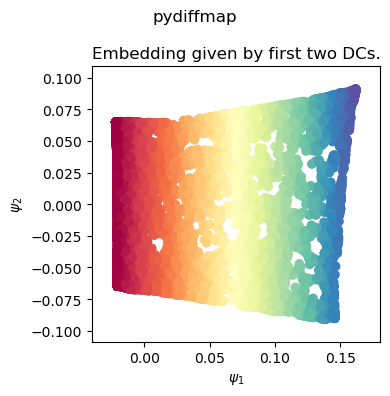

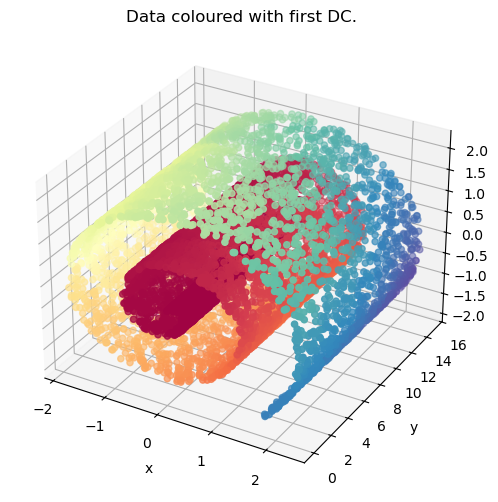

In [22]:
fig = embedding_plot(mydmap, dim=2,scatter_kwargs={'c': dmap[:,0], 'cmap':'Spectral','vmin':plot_1_min, 'vmax':plot_1_max}, show=False)
fig.set_size_inches((4,4))
plt.xlim(plot_1_min-p1b, plot_1_max + p1b)
plt.ylim(plot_2_min-p2b, plot_2_max + p2b)
fig.suptitle('pydiffmap')
fig.tight_layout()
plt.show()

fig = data_plot(mydmap, dim=3, n_evec=1,scatter_kwargs={'cmap':'Spectral', 'vmin':plot_1_min, 'vmax':plot_1_max})
fig.set_size_inches((4,4))


### Next we do the same for my diffusion maps code:

IndexError: index 2 is out of bounds for axis 1 with size 2

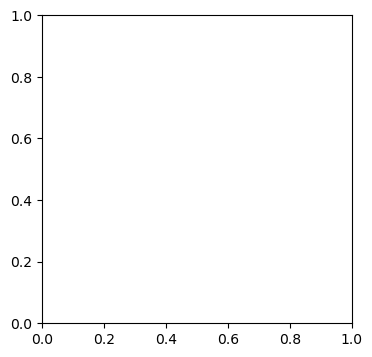

In [31]:
fig, ax = plt.subplots(figsize=(4,4))
plt.scatter(emb[:,1], emb[:,2], c= emb[:,1], cmap='Spectral') 
plt.show()


fig, ax = plt.subplots(figsize=(4,4), subplot_kw={'projection':'3d'})
scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=emb[:,1], cmap='Spectral', s=10)

### The scales in diffusion space for each embedding are quite different. Let's look at my code's in the context of the pydiffmap implementation.

#### Careful with interpretation here - it's not like each embedding is necessarily describing the same eigenfunction (i.e. the first embedding from one method is not the same as the first embedding from the other - for some reason). I do think that it would be preferable to have our embedding exist over a larger range of values in diffusion space, but what do I know?

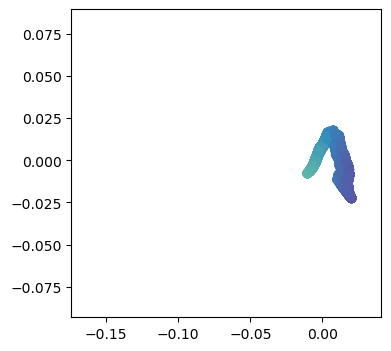

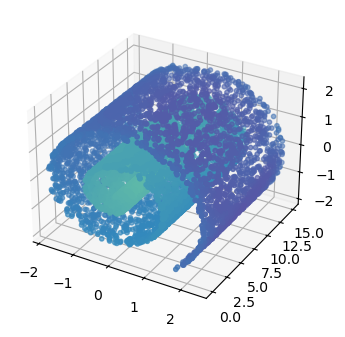

In [36]:
fig, ax = plt.subplots(figsize=(4,4))
plt.scatter(emb[:,1], emb[:,2], c= emb[:,1], cmap='Spectral',vmin= plot_1_min, vmax=plot_1_max) 
plt.xlim(plot_1_min-p1b, plot_1_max + p1b)
plt.ylim(plot_2_min-p2b, plot_2_max + p2b)
plt.show()


fig, ax = plt.subplots(figsize=(4,4), subplot_kw={'projection':'3d'})
scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=emb[:,1], cmap='Spectral',vmin= plot_1_min, vmax=plot_1_max, s=10)

#### So our code for some reason has a qualitatively quite different (and seemingly less sensitive) embedding. Why? To start, let's take a look at the diffusion operators we end up constructing (i.e. the matrices we end up taking eigendecompositions of):

### The pydiffmap operator seems a bit denser, but both look qualitatively like what we expect. However, the magnitudes of the values in each matrix are very different:

### ... this is where I am now as far as understanding how these two are different is concerned - the next step will be to follow the 'life cycle' of the training data as it evolves through both algorithms to understand what's happening differently.

## In the meantime, I've looked at what changing the $\alpha$ parameter (which is included by default in the pydiffmap code) does with the swiss roll:

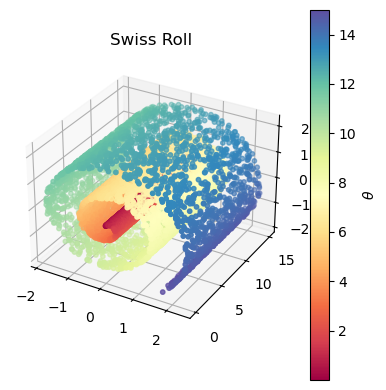

In [37]:
X_nonu, t_nonu = make_sw_pdm(10000, 1.5)
fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_nonu[:, 0], X_nonu[:, 1], X_nonu[:, 2], c=t_nonu, cmap='Spectral', s=10)
ax.set_title("Swiss Roll")
plt.colorbar(scatter, ax=ax, label="$\\theta$")
plt.tight_layout()
plt.show()
plt.close()

### Looking at the first couple embeddings when $\alpha = 0$ and $\alpha = 1$ for my code and pydiffmap:

In [38]:
neighbor_params = {'n_jobs': -1, 'algorithm': 'ball_tree'}
dm_a1 = dm.DiffusionMap.from_sklearn(n_evecs=2, k=300, epsilon=0.03125, alpha=1.0, neighbor_params=neighbor_params)
dmap_a1 = dm_a1.fit_transform(X_nonu)
dm_a0 = dm.DiffusionMap.from_sklearn(n_evecs=2, k=300, epsilon=0.03125, alpha=0.0, neighbor_params=neighbor_params)
dmap_a0 = dm_a0.fit_transform(X_nonu)

eig_vecs, eig_vals, a_train, bw, keeps= dap.MISC.diff_map(X_nonu, Neig=2, knn=300, bw=0.03125, eigmin=0.0, Ns=1, train_frac=1, alpha = 1.0)
eig_vecs0, eig_vals0, a_train, bw, keeps = dap.MISC.diff_map(X_nonu, Neig=2, knn=300, bw=0.03125, eigmin=0.0, Ns=1, train_frac=1, alpha = 0.0)
emb1 = (eig_vecs * eig_vals)
emb0 = (eig_vecs0 * eig_vals0)

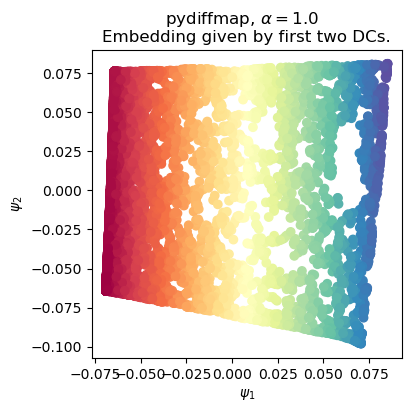

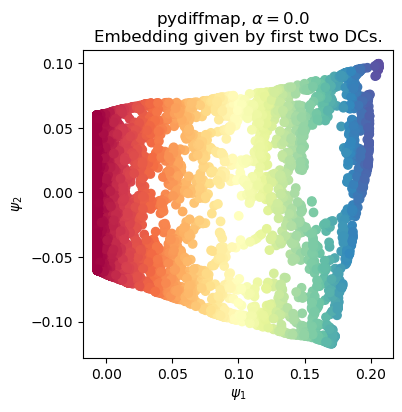

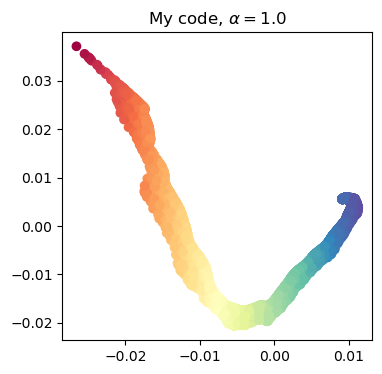

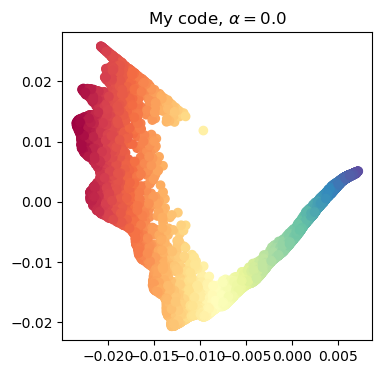

In [39]:
fig = embedding_plot(dm_a1, dim=2,scatter_kwargs={'c': dmap_a1[:,0], 'cmap':'Spectral'}, show=False)
fig.set_size_inches((4,4))
plt.suptitle('pydiffmap, $\\alpha=1.0$')
plt.show()
fig = embedding_plot(dm_a0, dim=2,scatter_kwargs={'c': dmap_a0[:,0], 'cmap':'Spectral'}, show=False)
fig.set_size_inches((4,4))
plt.suptitle('pydiffmap, $\\alpha=0.0$')
plt.show()

fig, ax = plt.subplots(figsize=(4,4))
plt.title('My code, $\\alpha=1.0$')
plt.scatter(emb1[:,1], emb1[:,2], c= emb1[:,1], cmap='Spectral') 
plt.show()

fig, ax = plt.subplots(figsize=(4,4))
plt.title('My code, $\\alpha=0.0$')
plt.scatter(emb0[:,1], emb0[:,2], c= emb0[:,1], cmap='Spectral') 
plt.show()

### And with even more nonuniform sampling:

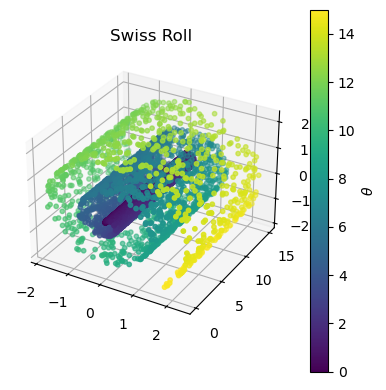

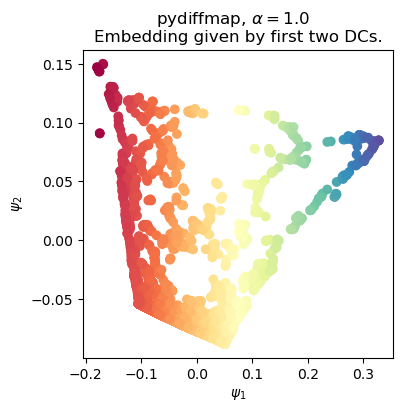

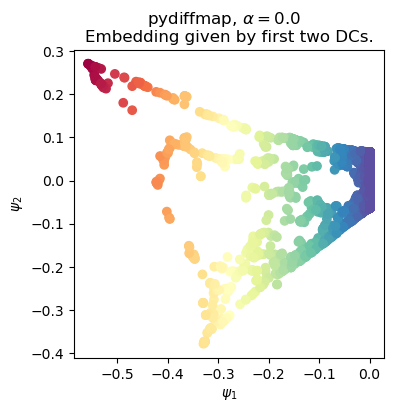

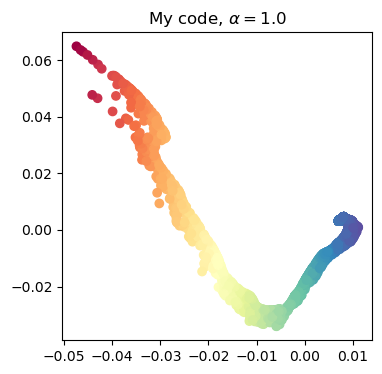

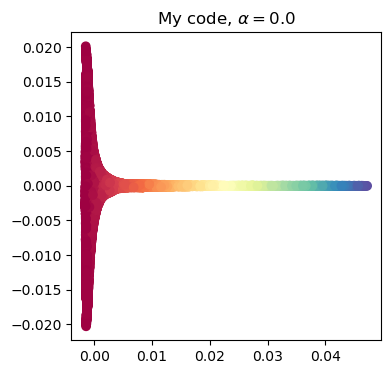

In [40]:

X_nonu, t_nonu = make_sw_pdm(10000, 5.0)
fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_nonu[:, 0], X_nonu[:, 1], X_nonu[:, 2], c=t_nonu, cmap=plt.cm.viridis, s=10)
ax.set_title("Swiss Roll")
plt.colorbar(scatter, ax=ax, label="$\\theta$")
plt.tight_layout()
plt.show()
plt.close()

neighbor_params = {'n_jobs': -1, 'algorithm': 'ball_tree'}
dm_a1 = dm.DiffusionMap.from_sklearn(n_evecs=2, k=300, epsilon=0.03125, alpha=1.0, neighbor_params=neighbor_params)
dmap_a1 = dm_a1.fit_transform(X_nonu)
dm_a0 = dm.DiffusionMap.from_sklearn(n_evecs=2, k=300, epsilon=0.03125, alpha=0.0, neighbor_params=neighbor_params)
dmap_a0 = dm_a0.fit_transform(X_nonu)

eig_vecs, eig_vals, a_train, bw, keeps= dap.MISC.diff_map(X_nonu, Neig=2, knn=300, bw=0.03125, eigmin=0.0, Ns=1, train_frac=1, alpha = 1.0)
eig_vecs0, eig_vals0, a_train, bw, keeps = dap.MISC.diff_map(X_nonu, Neig=2, knn=300, bw=0.03125, eigmin=0.0, Ns=1, train_frac=1, alpha = 0.0)
emb1 = (eig_vecs * eig_vals)
emb0 = (eig_vecs0 * eig_vals0)

fig = embedding_plot(dm_a1, dim=2,scatter_kwargs={'c': dmap_a1[:,0], 'cmap':'Spectral'}, show=False)
fig.set_size_inches((4,4))
plt.suptitle('pydiffmap, $\\alpha=1.0$')
plt.show()
fig = embedding_plot(dm_a0, dim=2,scatter_kwargs={'c': dmap_a0[:,0], 'cmap':'Spectral'}, show=False)
fig.set_size_inches((4,4))
plt.suptitle('pydiffmap, $\\alpha=0.0$')
plt.show()

fig, ax = plt.subplots(figsize=(4,4))
plt.title('My code, $\\alpha=1.0$')
plt.scatter(emb1[:,1], emb1[:,2], c= emb1[:,1], cmap='Spectral') 
plt.show()

fig, ax = plt.subplots(figsize=(4,4))
plt.title('My code, $\\alpha=0.0$')
plt.scatter(emb0[:,1], emb0[:,2], c= emb0[:,1], cmap='Spectral') 
plt.show()

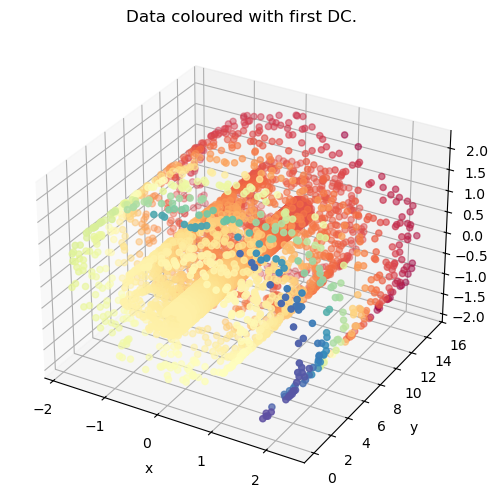

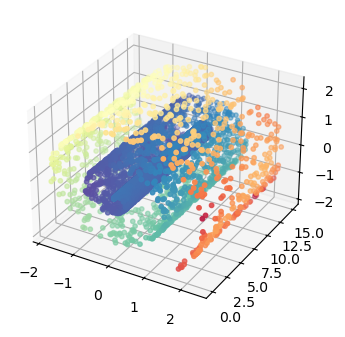

In [41]:
fig = data_plot(dm_a1, dim=3, n_evec=1,scatter_kwargs={'cmap':'Spectral'})
fig.set_size_inches((4,4))
fig, ax = plt.subplots(figsize=(4,4), subplot_kw={'projection':'3d'})
scatter = ax.scatter(X_nonu[:, 0], X_nonu[:, 1], X_nonu[:, 2], c=emb1[:,1], cmap='Spectral', s=10)

# Now to start tracking what happens in each algorithm, starting with the same training data:

## First, my code:

In [42]:

rng = np.random.default_rng(58)
np.set_printoptions(suppress=True)

### Some random sample data; 10 2-dimensional points)

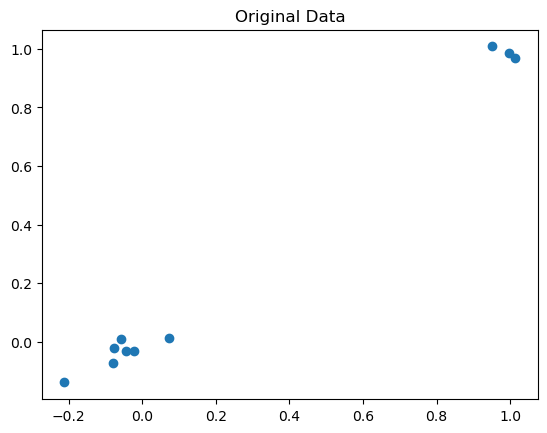

In [43]:
rng = np.random.default_rng(58)
arr = np.zeros((10,2))
arr[:7] = rng.normal(0, 0.1, size=(7,2))
arr[7:] = rng.normal(1,0.05, size=(3,2))

plt.scatter(arr[:,0], arr[:,1])
plt.title('Original Data')
plt.show()
plt.close()

k = 3
eps = 0.5
alpha = 0.0

### Step 1: Scale all of the features in the dataset so that the maximum of any given feature is 1. 
Does this fully make sense? I'm suspicious for some reason.

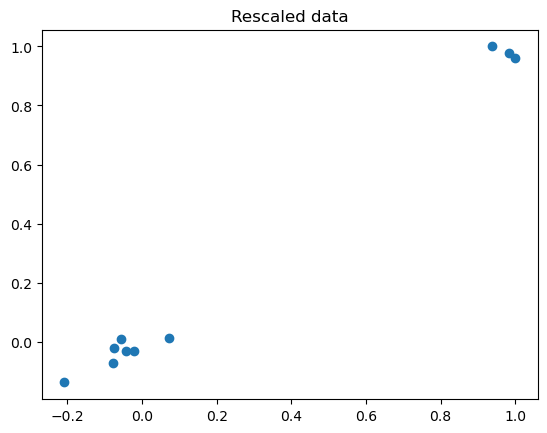

In [44]:
vt = arr.copy()
for i in range(2):
    denom = np.max(np.abs(vt[:, i]))
    if denom > 0:
        vt[:, i] /= denom

arr = vt
plt.scatter(arr[:,0], arr[:,1])
plt.title('Rescaled data')
plt.show()
plt.close()


### Step 2: Form the matrix of pairwise distances between each point in the dataset

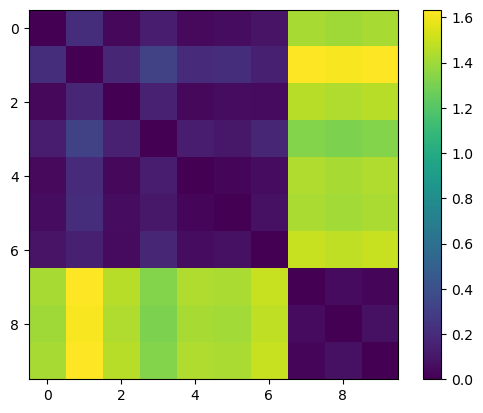

In [45]:
D = squareform(pdist(arr))
plt.imshow(D)
plt.colorbar()
plt.show()
plt.close()

### Steps 3+4 done together:
Step 3: Identify the k nearest neighbors to each point using the distance matrix, and thin out the distance matrix to retain only those entries. Ensure that the matrix is still symmetric by taking the maximum of the resulting sparse matrix and its transpose.

Step 4: Compute matrix of jump probabilities that describes how likely it is that we jump from one point to any of the other points by plugging each distance into the Gaussian RBF with bandwidth $\epsilon$.

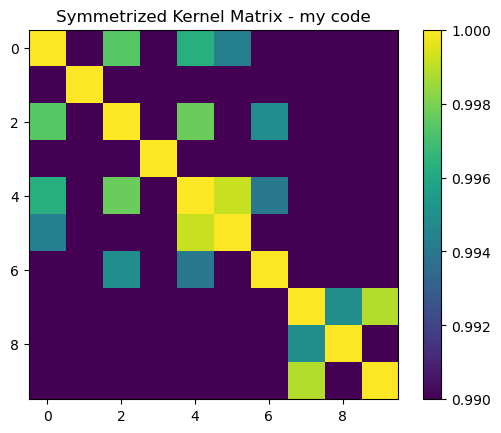

In [47]:
from scipy.sparse import csr_matrix, diags
from scipy.sparse.linalg import eigs, eigsh

# STEP 3
srtd_idx = np.argsort(D, axis=1)
dt = np.take_along_axis(D, srtd_idx[:, :3], axis=1)
nidx = srtd_idx[:, :3]

# INTERMISSION: STEP 4
temp_w = np.exp(-(dt**2) / eps)
# BACK TO STEP 3
row_idx = np.repeat(np.arange(10), 3)
W = csr_matrix((temp_w.ravel(), (row_idx, nidx.ravel())), shape=(10,10))
W = (W.T).maximum(W)
Wsym = W
plt.imshow(W.toarray(), vmin=0.99, vmax=1.0)
plt.title('Symmetrized Kernel Matrix - my code')
plt.colorbar()
plt.show()
plt.close()


### STEP 5: $\alpha$-normalization. Approximate the sampling density $p(x_n)$ as $\sum_{i\neq n} k(x_n, x_i)$. Then we let $[W]_{ij} \leftarrow \frac{[W]_{ij}}{p(x_i)^\alpha p(x_j)^\alpha}$


#### For now, we're keeping $\alpha = 0$ for simplicity.

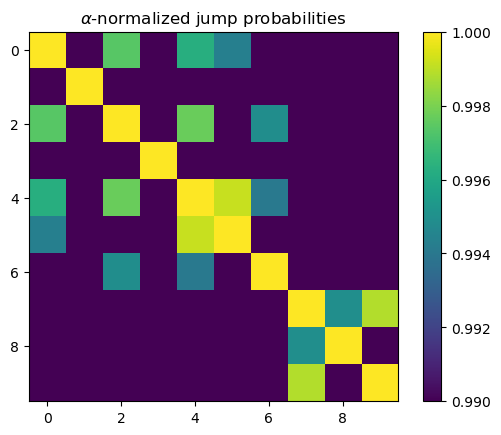

In [48]:
q = np.array(W.sum(axis=1)).ravel() + 1e-16
if alpha != 0.0:
      dq = diags(q**-alpha)
      W_norm = dq @ W @ dq
else:
      W_norm = W

W = W_norm

if alpha != 0.0:
    plt.imshow(dq.toarray())
    plt.colorbar()
    plt.title('Density Estimates for each data point')
    plt.show()
    plt.close()
plt.imshow(W.toarray(), vmin=0.99, vmax=1.0)
plt.title('$\\alpha$-normalized jump probabilities')
plt.colorbar()
plt.show()
plt.close()

### Step 6: Compute row sums of the weight matrix and... normalize by them? This seems suspiciously identical to what the $\alpha$ normalization looks like. We're taking the row sum and dividing each jump probability by the product of its two entries' row sums. We then resymmetrize a second time and add a small bit to the diagonal to regularize the eigenvalue problem.

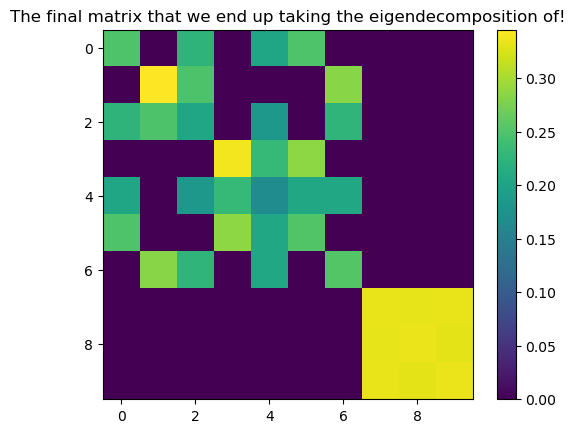

In [49]:
row_sum = np.array(W.sum(axis=1)).ravel()
alpha_train = 1.0 / np.sqrt(row_sum)
ld = diags(alpha_train)
DO = ld @ W @ ld
DO = (DO.T).maximum(DO)  # Ensure symmetr
DO = DO + 1e-10 * np.eye(10)

plt.imshow(DO)
plt.colorbar()
plt.title('The final matrix that we end up taking the eigendecomposition of!')
plt.show()
plt.close()

# Now we follow along with the pydiffmap algorithm! The actual pydiffmap code is super object oriented; for the purposes of this notebook, I'm going to do what it does in more of a procedural style to be able to compare my code and theirs apples to apples, while still ensuring that we get numerically the same output at each step.

In [50]:
# regenerate data
rng = np.random.default_rng(58)
arr = np.zeros((10,2))
arr[:7] = rng.normal(0, 0.1, size=(7,2))
arr[7:] = rng.normal(1,0.05, size=(3,2))

# for now for convenience in tracking similarities across methods, normalize features. pydiffmap usually doesn't do this.
vt = arr.copy()
for i in range(2):
    denom = np.max(np.abs(vt[:, i]))
    if denom > 0:
        vt[:, i] /= denom

arr = vt


### The first step is to construct the matrix of kernel evaluations as follows. This is done in the _build_kernel method of the DiffusionMap class:
1. fit the data to a sklearn NearestNeighbors object. This involves both identifying the nearest neighbors and computing the matrix of pairwise distances.
2. apply the kernel function to the sparse matrix of pairwise distances
3. Symmetrize the matrix.

### Major difference \#1! pydiffmap doesn't do any feature normalization. 

### Major difference \#2! pydiffmap defines their gaussian kernel as $\exp(-d^2 / 4 \epsilon)$, whereas we don't have the factor of 4, so what I thought was originally an apples to apples comparison above was using a significantly more sensitive kernel with pydiffmap than with my code. I've adjusted the epsilon used for this section to be one fourth of what it was before to compensate.

In [51]:

eps = 0.5/4

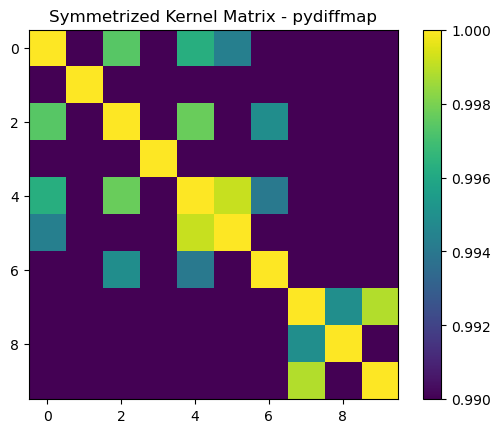

In [52]:
sknn = NearestNeighbors(n_neighbors = k, n_jobs=-1, algorithm='ball_tree')
sknn.fit(arr)
dists = sknn.kneighbors_graph(arr, mode='distance')
def gaussian_kfxn(d, epsilon):
    return np.exp(-d**2 / (4. * epsilon))
K = dists.copy()
K.data = gaussian_kfxn(dists.data, eps)
Ktrans = K.transpose()
dK = abs(K-Ktrans)
K = K + Ktrans + dK
Ksym = 0.5 * K
plt.imshow(Ksym.toarray(), vmin=0.99, vmax=1.0)
plt.title('Symmetrized Kernel Matrix - pydiffmap')
plt.colorbar()
plt.show()
plt.close()


### Next, we move on to the various normalization steps. First is what they call the "right normalization."

In [53]:
# compute the row sums of the kernel matrix
q = np.array(K.sum(axis=1)).ravel()
right_norm_vec = np.power(q, -alpha)
m = right_norm_vec.shape[0]
Dalpha = sps.spdiags(right_norm_vec, 0, m, m)
K_rn = Ksym * Dalpha

### Next is the "left normalization."

In [54]:
row_sum = K_rn.sum(axis=1).transpose()
n = row_sum.shape[1]
Dalpha = sps.spdiags(np.power(row_sum, -1), 0, n, n)
P = Dalpha * K_rn

    

### And a final step they call "build_generator.":

In [55]:
m, n = P.shape
L = (P - sps.eye(m, n, k=(n - m))) / eps

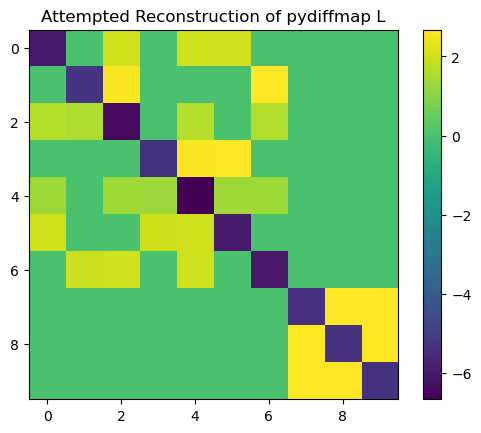

In [56]:
plt.imshow(L.toarray())
plt.title('Attempted Reconstruction of pydiffmap L')
plt.colorbar()
plt.show()
plt.close()

### Let's do a correctness check. Below we run the pydiffmap method construct_Lmat which constructs the transition matrix without computing the eigendecomposition (i.e. it returns the matrix that we do the eigendecomposition for), and save it into the variable Lcomp. 

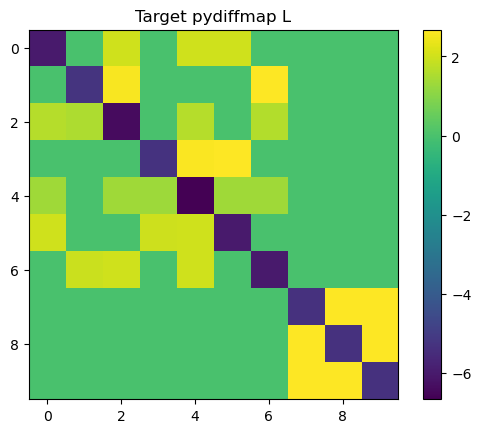

In [57]:
neighbor_params = {'n_jobs': -1, 'algorithm': 'ball_tree'}
compdm = dm.DiffusionMap.from_sklearn(n_evecs=2, k=3, epsilon=0.125, alpha=0.0, neighbor_params=neighbor_params)
compdm = compdm.construct_Lmat(arr)
Lcomp = compdm.L
plt.imshow(Lcomp.toarray())
plt.title('Target pydiffmap L')
plt.colorbar()
plt.show()
plt.close()


In [58]:
print((Lcomp - L).toarray())

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


## The pydiffmap gives a "transition matrix" that is radically different from the one our code makes, and in somewhat unintuitive ways: 

1. The diagonal is all negative. This feels very strange.
2. The row sums all sum to... 0?

### Accounting for differences in how epsilon is specified and with features that have been scaled the way we do so that the largest of each feature is 1, all of these differences come back to the various normalizations applied to the kernel matrix. What are the differences in what we're doing vs. what they're doing?

### Let $\alpha = 0$ for now. Given the matrix of kernel evaluations ($W$, in my code), my code starts with the following:

```
q = np.array(W.sum(axis=1)).ravel() + 1e-16
if alpha != 0.0:
      dq = diags(q**-alpha)
      W_norm = dq @ W @ dq
else:
      W_norm = W

W = W_norm
```

This will compute row sums of $W$, and then do nothing with them, because we never make it inside the if-statement.

We then proceed to do the normalization that makes the rows sum to 1:


```
row_sum = np.array(W.sum(axis=1)).ravel()
alpha_train = 1.0 / np.sqrt(row_sum)
ld = diags(alpha_train)
DO = ld @ W @ ld
DO = (DO.T).maximum(DO)  # Ensure symmetr
DO = DO + 1e-10 * np.eye(10)
```

The first line of this once again computes row sums. Recall that the row sums approximate the sampling density $\rho$. We then construct a diagonal matrix where the entries are one over the square root of the row sum (i.e., we let alpha_train = $\frac{1}{\rho^{0.5}}$ We multiply this diagonal matrix on the left and right side of $W$; this is equivalent to taking each entry $W_{ij}$ of $W$ and replacing it with $\frac{W_{ij}}{\rho(x_i)^{0.5}\rho(x_j)^{0.5}}$. Finally, we symmetrize the matrix, and it's ready to be sent off for eigendecomposition.


### Note: once again, despite setting $\alpha = 0$, it appears that in my original code already, we're already actually doing $\alpha$-normalization with $\alpha=0.5$. It seems that $\alpha=0.5$ is hard-coded into the original code we have both for diffusion maps and for the Nystroem extension (i.e. my python code and Jon's matlab code). 

### Note 2: Actually, nevermind. The matrix DO we construct above (pre-symmetrizationq) is similar to the matrix that you get by normalizing by row sums, so its eigenvalues are the same. However, the corresponding eigenvectors are not (or at least, they're written in a different basis - does this matter?)




### Now let's follow our way through the pydiffmaps normalizations:

Once again, with $\alpha =0$, we compute the row sum of the kernel matrix. We then construct the diagonal matrix that is in fact the identity (because the diagonals are computed as the inverses of the row sums raised to the power 0), and multiply by it; once again, nothing changes when $\alpha=0$.

```
q = np.array(K.sum(axis=1)).ravel()
right_norm_vec = np.power(q, -alpha)
m = right_norm_vec.shape[0]
Dalpha = sps.spdiags(right_norm_vec, 0, m, m)
K_rn = Ksym * Dalpha
```
So the pydiffmap "right normalization" seems to be what they're calling the $\alpha$-normalization.

Next is the "left normalization". This makes the matrix mentioned above that is similar to the one we take the eigendecomposition of in our code. This is the most intuitive form of the row normalization that takes the kernel matrix and turns it into a matrix of jump probabilities where the rows sum to 0:
```
row_sum = K_rn.sum(axis=1).transpose()
n = row_sum.shape[1]
Dalpha = sps.spdiags(np.power(row_sum, -1), 0, n, n)
P = Dalpha * K_rn
```

Finally, there's the "build_generator" step - this takes the Markov matrix and changes it into a transition *rate* matrix - which describes not the probability of going from state $i$ to state $j$ but the instantaneous rate of transition from state $i$ to state $j$. The below is a first-order approximation of the transition rate matrix that is reasonable when the time step (our $\epsilon$) is small:
```
m, n = P.shape
L = (P - sps.eye(m, n, k=(n - m))) / eps
```

# Let's try something that I think is the most straightforward: doing $\alpha$-normalization, but with the "standard" row normalization that gives us rows that sum to 0, and no feature normalization:
## I've added some options in this code to toggle the feature normalization on and off and to switch back and forth between the standard row normalization and the one we've been doing. With feature normalization on and the symmetric row normalization, this is equivalent to our previous code.

In [4]:
def dmap_hms(data, Neig, knn, bw, Ns, alpha, f_normalize=True, symmetric_row_normalize=True):

    def gaussian_k(d, bw):
        return np.exp(-d**2 / bw)
    
    rng = np.random.default_rng(58)
    N,M = data.shape
    scaled_data = data.copy()
    if f_normalize:
        for i in range(M):
            denom = np.max(np.abs(scaled_data[:, i]))
            if denom > 0:
                scaled_data[:, i] /= denom
    sknn = NearestNeighbors(n_neighbors=knn, n_jobs=-1, algorithm='ball_tree')
    sknn.fit(scaled_data)
    dists = sknn.kneighbors_graph(scaled_data, mode='distance')
    K = dists.copy()
    K.data = gaussian_k(dists.data, bw)
    Ksym = (K.T).maximum(K)

    # alpha normalization
    q = np.array(K.sum(axis=1)).ravel()
    right_norm_vec = np.power(q, -alpha)
    m = right_norm_vec.shape[0]
    Dalpha = sps.spdiags(right_norm_vec, 0, m, m)
    K_rn = Ksym @ Dalpha

    # row normalization
    if symmetric_row_normalize:
        row_sum = K_rn.sum(axis=1).ravel()
        inv_row_sum = np.power(row_sum, -0.5)
        n = row_sum.shape[1]
        Dalpha = sps.spdiags(inv_row_sum, 0, n, n)
        P = Dalpha @ K_rn @ Dalpha
    else:
        row_sum = K_rn.sum(axis=1).ravel()
        inv_row_sum = np.power(row_sum, -1)
        n = row_sum.shape[1]
        Dalpha = sps.spdiags(inv_row_sum, 0, n, n)
        P = Dalpha @ K_rn

    P = P + 1e-10 * np.eye(n)

    evals, evecs = spsl.eigs(P, k=Neig+1, which='LR')

    ix = evals.argsort()[::-1][1:]
    evals = np.real(evals[ix])
    evecs = np.real(evecs[:, ix])

    a_signs = np.where(evecs[0] < 0, -1, 1)
    evecs *= a_signs

    return evecs, evals, inv_row_sum, scaled_data
 

    
    
    
    
    

### Testing/comparison: first, confirming that this new one is equivalent to the old one with the right settings:

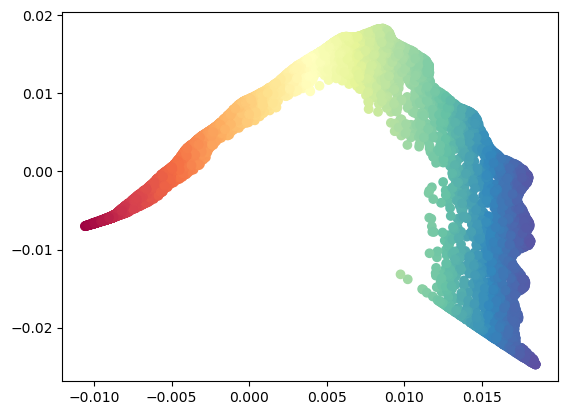

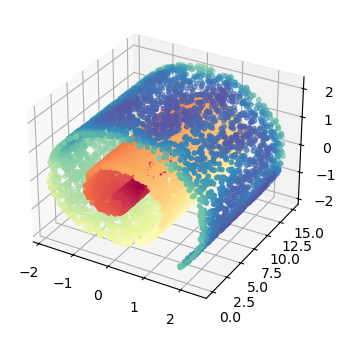

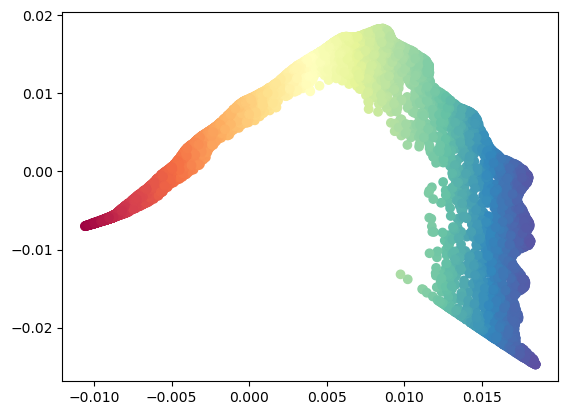

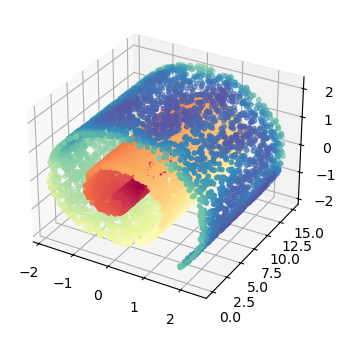

In [28]:
eig_vecs, eig_vals, a_train, scaled = dmap_hms(X, Neig=2, knn=300, bw=0.03125, Ns=1, alpha = 0.0, symmetric_row_normalize=True, f_normalize=True)
eig_vecs2, eig_vals2, a_train, bw, keeps = dap.MISC.diff_map(X, Neig=2, knn=300, bw=0.03125, eigmin=0.0, Ns=1, train_frac=1, alpha = 0.0)
emb = (eig_vecs * eig_vals)
emb2 = (eig_vecs2 * eig_vals2)
plt.scatter(emb[:,0], emb[:,1], c= emb[:,0], cmap='Spectral') 
plt.show()
fig, ax = plt.subplots(figsize=(4,4), subplot_kw={'projection':'3d'})
scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=emb[:,0], cmap='Spectral', s=10)
plt.show()


plt.scatter(emb2[:,1], emb2[:,2], c= emb2[:,1], cmap='Spectral') 
plt.show()
fig, ax = plt.subplots(figsize=(4,4), subplot_kw={'projection':'3d'})
scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=emb2[:,1], cmap='Spectral', s=10)
plt.show()

### What if we keep feature normalization, but switch to the standard row normalization?

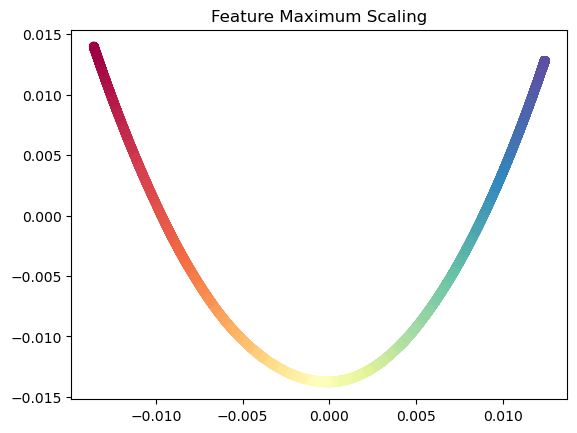

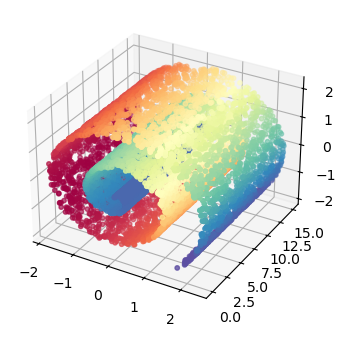

In [33]:
eig_vecs, eig_vals, a_train, scaled = dmap_hms(X, Neig=10, knn=300, bw=0.003125, Ns=1, alpha = 1.0, symmetric_row_normalize=False, f_normalize=True)
emb = (eig_vecs * eig_vals)
plt.scatter(emb[:,0], emb[:,1], c= emb[:,0], cmap='Spectral') 
plt.title('Feature Maximum Scaling')
plt.show()
fig, ax = plt.subplots(figsize=(4,4), subplot_kw={'projection':'3d'})
scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=emb[:,1], cmap='Spectral', s=10)
plt.show()

### And if we turn off feature normalization (without even changing the bandwidth, although this would be a reasonable thing to do):

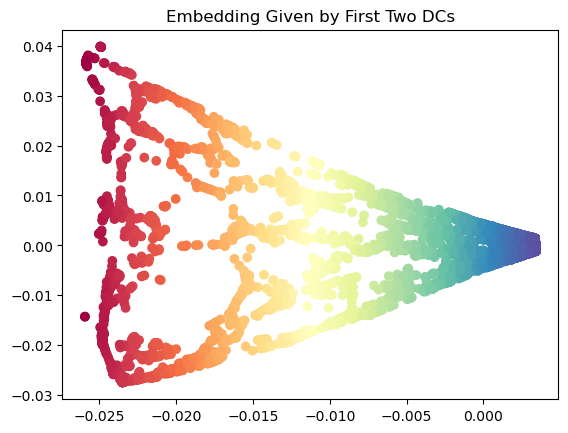

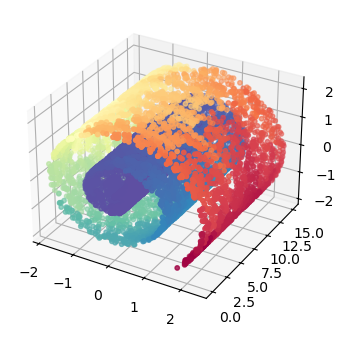

In [36]:
eig_vecs, eig_vals, a_train, scaled = dmap_hms(X, Neig=2, knn=300, bw=0.03125, Ns=1, alpha = 0.0, symmetric_row_normalize=False, f_normalize=False)
emb = (eig_vecs * eig_vals)
plt.scatter(emb[:,0], emb[:,1], c= emb[:,0], cmap='Spectral') 
plt.title('Embedding Given by First Two DCs')
plt.show()
fig, ax = plt.subplots(figsize=(4,4), subplot_kw={'projection':'3d'})
scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=emb[:,0], cmap='Spectral', s=10)
plt.show()

### Setting $\alpha = 1$ now also has the expected behavior:

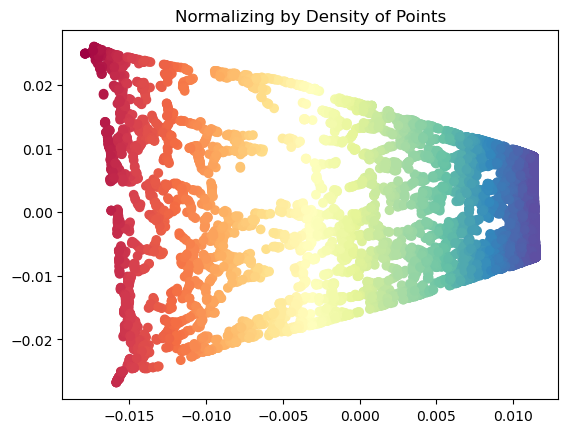

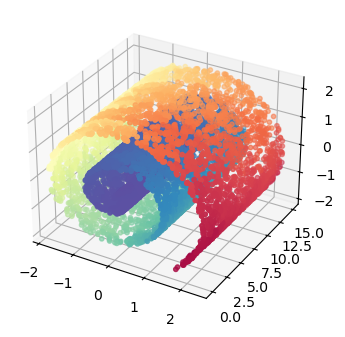

In [65]:
eig_vecs, eig_vals, a_train, scaled = dmap_hms(X, Neig=2, knn=300, bw=0.03125, Ns=1, alpha = 1.0, symmetric_row_normalize=False, f_normalize=False)
emb = (eig_vecs * eig_vals)
plt.scatter(emb[:,0], emb[:,1], c= emb[:,0], cmap='Spectral') 
plt.title('Normalizing by Density of Points')
plt.show()
fig, ax = plt.subplots(figsize=(4,4), subplot_kw={'projection':'3d'})
scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=emb[:,0], cmap='Spectral', s=10)
plt.show()

## Finally, if we do do the symmetric row normalization but don't do feature scaling:

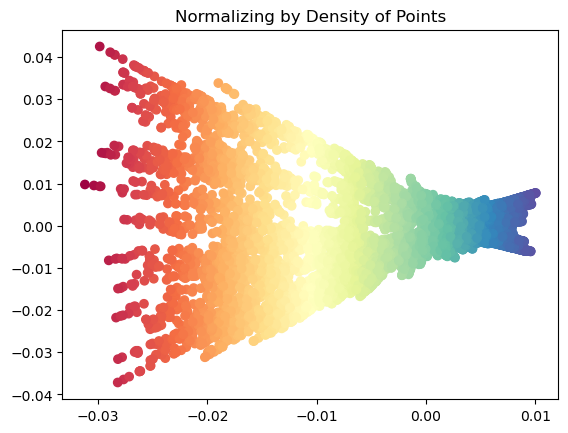

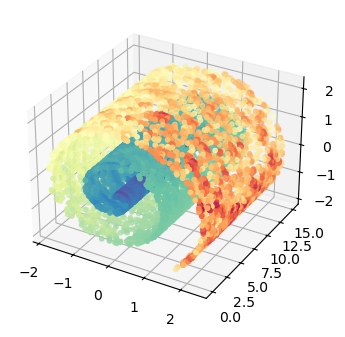

In [66]:
eig_vecs, eig_vals, a_train, scaled = dmap_hms(X, Neig=2, knn=300, bw=0.03125, Ns=1, alpha = 0.0, symmetric_row_normalize=True, f_normalize=False)
emb = (eig_vecs * eig_vals)
plt.scatter(emb[:,0], emb[:,1], c= emb[:,0], cmap='Spectral') 
plt.title('Normalizing by Density of Points')
plt.show()
fig, ax = plt.subplots(figsize=(4,4), subplot_kw={'projection':'3d'})
scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=emb[:,0], cmap='Spectral', s=10)
plt.show()

# So we've learned that the default row normalization probably makes more sense to do, but also that the feature normalization can do some weird things. On one hand, the feature normalization is advantageous because it allows bandwidth selection to be standardized and relatively interpretable. It also *seems* like it would be useful when we have multiple different types of features that tend to have significantly different magnitudes. On the other hand, doing it per individual feature changes the shape of the manifold the data is living on and so significanly affects results.

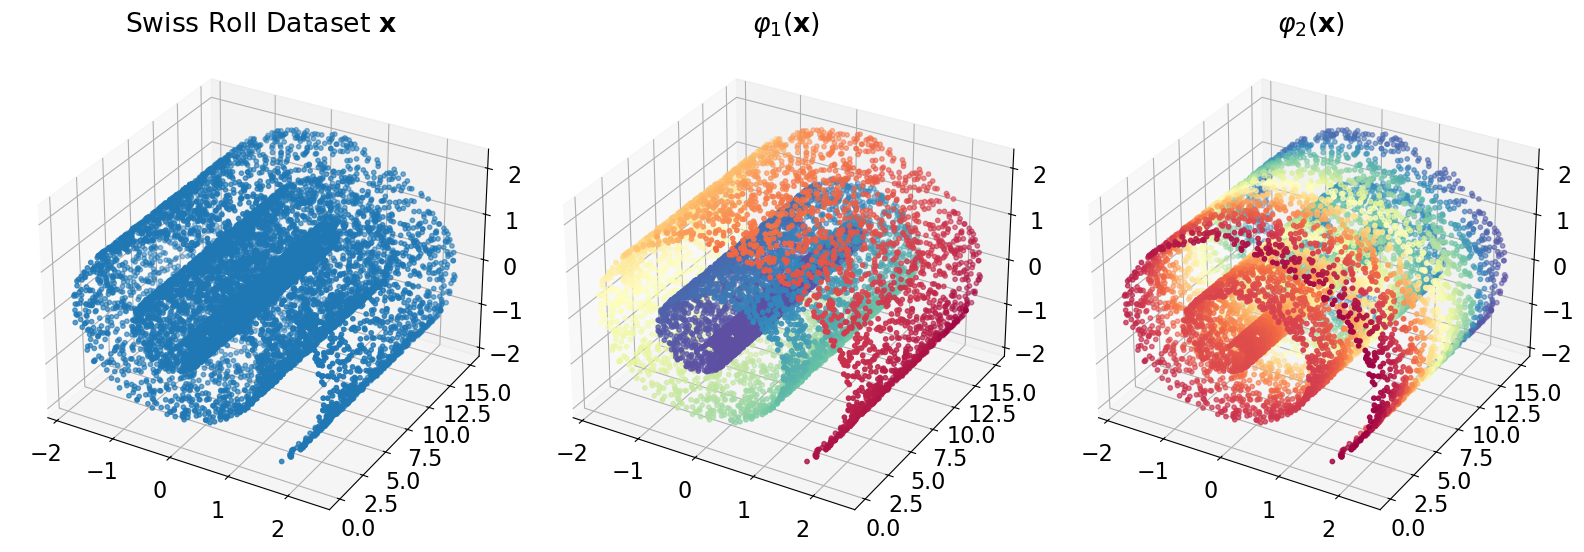

In [15]:
#X_nonu, t_nonu = make_sw_pdm(10000, 1.0)
plt.rcParams.update({'font.size': 16})

fig, axs = plt.subplots(1,3,figsize=(16,10), subplot_kw={'projection':'3d'})
scatter = axs[0].scatter(X_nonu[:, 0], X_nonu[:, 1], X_nonu[:, 2], s=10)
axs[0].set_title("Swiss Roll Dataset $\\mathbf{x}$")

#eig_vecs, eig_vals, a_train, scaled = dmap_hms(X_nonu, Neig=2, knn=300, bw=0.075, Ns=1, alpha = 1.0, symmetric_row_normalize=False, f_normalize=False)
emb = (eig_vecs * eig_vals)
scatter = axs[1].scatter(X_nonu[:, 0], X_nonu[:, 1], X_nonu[:, 2], c=emb[:,0], cmap='Spectral', s=10)
axs[1].set_title("$\\varphi_1(\\mathbf{x})$")

scatter = axs[2].scatter(X_nonu[:, 0], X_nonu[:, 1], X_nonu[:, 2], c=emb[:,1], cmap='Spectral', s=10)
axs[2].set_title("$\\varphi_2(\\mathbf{x})$")
plt.tight_layout()
plt.savefig('swiss_roll_prop.png')
plt.show()
plt.close()

In [37]:
X.shape

(10000, 3)

In [38]:
X_nonu.shape

(2000, 3)